In [ ]:
!pip install -U transformers

In [ ]:
!pip install -q transformers datasets evaluate

import pandas as pd
import torch
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)

from datasets import Dataset

In [ ]:
def load_dataset(file_path):
    try:
        if file_path.endswith(".csv"):
            try:
                return pd.read_csv(file_path, low_memory=False, encoding="utf-8")
            except:
                try:
                    return pd.read_csv(file_path, low_memory=False, encoding="latin-1")
                except:
                    return pd.read_csv(file_path, low_memory=False, encoding="cp1252")

        elif file_path.endswith(".jsonl"):
            return pd.read_json(file_path, lines=True)

        elif file_path.endswith(".json"):
            return pd.read_json(file_path)

        elif file_path.endswith(".xlsx"):
            return pd.read_excel(file_path)

    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None

In [ ]:
def normalize_columns(df):
    df = df.copy()

    text_cols = ["text", "email_text", "content", "body", "message"]
    subject_cols = ["subject", "title"]

    subject = ""
    body = ""

    for col in subject_cols:
        if col in df.columns:
            subject = df[col].astype(str).fillna("")
            break

    for col in text_cols:
        if col in df.columns:
            body = df[col].astype(str).fillna("")
            break

    df["text"] = subject + " " + body

    possible_label_cols = ["label", "class", "is_phishing", "target", "spam", "category"]

    label_col = None
    for col in possible_label_cols:
        if col in df.columns:
            label_col = col
            break

    if label_col is None:
        return None

    def map_label(val):
        if isinstance(val, str):
            val = val.lower().strip()
            if val in ["phishing", "spam", "scam", "malicious"]:
                return 1
            if val in ["benign", "legitimate", "ham", "safe"]:
                return 0
        else:
            if val in [1, "1"]:
                return 1
            if val in [0, "0"]:
                return 0
        return None

    df["label"] = df[label_col].apply(map_label)
    df = df[["text", "label"]].dropna()
    df["label"] = df["label"].astype(int)

    return df

In [ ]:
dataset_files = [
    "/content/drive/MyDrive/Email_Datasets_for_fyp/FinalDatasetForEmail/spamResults.csv",
    "/content/drive/MyDrive/Email_Datasets_for_fyp/FinalDatasetForEmail/phishing and benign email dataset.jsonl",
    "/content/drive/MyDrive/Email_Datasets_for_fyp/FinalDatasetForEmail/enron_spam_data.csv",
    "/content/drive/MyDrive/Email_Datasets_for_fyp/FinalDatasetForEmail/email.xlsx",
    "/content/drive/MyDrive/Email_Datasets_for_fyp/FinalDatasetForEmail/SpamAssasin.csv",
    "/content/drive/MyDrive/Email_Datasets_for_fyp/FinalDatasetForEmail/Phishing_validation_emails.csv",
    "/content/drive/MyDrive/Email_Datasets_for_fyp/FinalDatasetForEmail/PhishingEmailDataset_1.csv",
    "/content/drive/MyDrive/Email_Datasets_for_fyp/FinalDatasetForEmail/Nigerian_Fraud.csv",
    "/content/drive/MyDrive/Email_Datasets_for_fyp/FinalDatasetForEmail/Nazario.csv",
    "/content/drive/MyDrive/Email_Datasets_for_fyp/FinalDatasetForEmail/Ling.csv",
    "/content/drive/MyDrive/Email_Datasets_for_fyp/FinalDatasetForEmail/Enron1.csv",
    "/content/drive/MyDrive/Email_Datasets_for_fyp/FinalDatasetForEmail/Enron.csv",
    "/content/drive/MyDrive/Email_Datasets_for_fyp/FinalDatasetForEmail/Email_scam.csv",
    "/content/drive/MyDrive/Email_Datasets_for_fyp/FinalDatasetForEmail/CEAS_08.csv"
]

dfs = []

for file in dataset_files:
    df = load_dataset(file)
    if df is None:
        continue

    df = normalize_columns(df)
    if df is not None and len(df) > 0:
        dfs.append(df)

final_df = pd.concat(dfs, ignore_index=True)

print("Total samples:", len(final_df))
print(final_df["label"].value_counts())

Total samples: 88258
label
0    44520
1    43738
Name: count, dtype: int64


In [ ]:
MAX_SAMPLES = 10000

if len(final_df) > MAX_SAMPLES:
    final_df = final_df.sample(MAX_SAMPLES, random_state=42)

In [ ]:
train_df, test_df = train_test_split(
    final_df,
    test_size=0.2,
    stratify=final_df["label"],
    random_state=42
)

In [ ]:
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

In [ ]:
model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

train_dataset = train_dataset.remove_columns(["text"])
test_dataset = test_dataset.remove_columns(["text"])

train_dataset.set_format(type='torch')
test_dataset.set_format(type='torch')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)

    return {
        "accuracy": (preds == labels).mean(),
        "precision": precision_score(labels, preds),
        "recall": recall_score(labels, preds),
        "f1": f1_score(labels, preds)
    }

In [ ]:
import transformers
print(transformers.__version__)

5.5.0


In [ ]:
training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/Email_Datasets_for_fyp/ML_Output",

    learning_rate=2e-5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    num_train_epochs=3,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,

    logging_steps=100,
    save_total_limit=2,

    report_to="none"
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

In [ ]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.111249,0.157794,0.960500,0.997805,0.921907,0.958355


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.111249,0.157794,0.960500,0.997805,0.921907,0.958355
2,0.033570,0.108745,0.978000,0.989605,0.965517,0.977413
3,0.023690,0.099922,0.982000,0.989691,0.973631,0.981595


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=3000, training_loss=0.07584634672974547, metrics={'train_runtime': 17626.7222, 'train_samples_per_second': 1.362, 'train_steps_per_second': 0.17, 'total_flos': 794804391936000.0, 'train_loss': 0.07584634672974547, 'epoch': 3.0})

In [ ]:
results = trainer.predict(test_dataset)
print(results.metrics)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'test_loss': 0.09992191940546036, 'test_accuracy': 0.982, 'test_precision': 0.9896907216494846, 'test_recall': 0.973630831643002, 'test_f1': 0.9815950920245399, 'test_runtime': 392.4977, 'test_samples_per_second': 5.096, 'test_steps_per_second': 0.637}


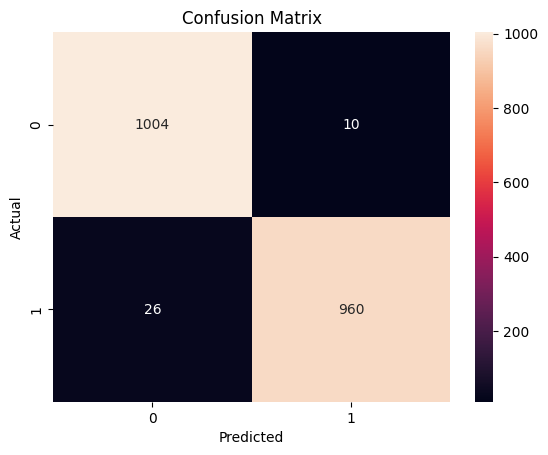

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1014
           1       0.99      0.97      0.98       986

    accuracy                           0.98      2000
   macro avg       0.98      0.98      0.98      2000
weighted avg       0.98      0.98      0.98      2000



In [ ]:
y_true = []
y_pred = []

for batch in test_dataset:
    inputs = {k: batch[k].unsqueeze(0) for k in ["input_ids", "attention_mask"]}
    labels = batch["label"].item()

    with torch.no_grad():
        outputs = model(**inputs)

    pred = torch.argmax(outputs.logits, dim=-1).item()

    y_true.append(labels)
    y_pred.append(pred)

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_true, y_pred))

In [ ]:
save_path = "/content/drive/MyDrive/Email_Datasets_for_fyp/ML_Output"
os.makedirs(save_path, exist_ok=True)

model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/Email_Datasets_for_fyp/ML_Output/tokenizer_config.json',
 '/content/drive/MyDrive/Email_Datasets_for_fyp/ML_Output/tokenizer.json')